# Modelo de regresion Logistica final

In [19]:
# Incluir librerias a utilizar
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


## Carga y limpieza inicial
Estas son transformaciones que dependen de la lógica del negocio y se hacen antes del pipeline.

In [20]:
df = pd.read_csv('archive/base.csv') # Asegúrate que el nombre del archivo sea correcto

In [21]:
# Manejo de valores centinela (-1)
df['prev_address_unknown'] = df['prev_address_months_count'].apply(lambda x: 1 if x == -1 else 0)
df['prev_address_months_count'] = df['prev_address_months_count'].replace(-1, 0)
df['bank_months_unknown'] = df['bank_months_count'].apply(lambda x: 1 if x == -1 else 0)
df['bank_months_count'] = df['bank_months_count'].replace(-1, 0)
median_session = df[df['session_length_in_minutes'] != -1]['session_length_in_minutes'].median()
df['session_length_in_minutes'] = df['session_length_in_minutes'].replace(-1, median_session)

# Eliminación de columnas correlacionadas
df = df.drop(columns=['velocity_6h', 'velocity_24h'])

## PREPARACIÓN PARA EL PIPELINE

In [22]:
# 1. Separar características (X) y variable objetivo (y)
X = df.drop('fraud_bool', axis=1)
y = df['fraud_bool']

# 2. Identificar columnas numéricas y categóricas que irán al pipeline
numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()

# 3. Dividir los datos ANTES de aplicar el pipeline
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## Construccion del pipeline

In [23]:
# Función personalizada para el recorte de outliers con IQR
def clip_outliers_iqr(df):
    df_copy = df.copy()
    for col in df_copy.columns:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df_copy[col] = df_copy[col].clip(lower=limite_inferior, upper=limite_superior)
    return df_copy

# 4. Crear el pipeline para transformaciones numéricas
#    Paso 1: Recortar outliers.
#    Paso 2: Escalar los datos.
numeric_transformer = Pipeline(steps=[
    ('outlier_clipper', FunctionTransformer(clip_outliers_iqr)),
    ('scaler', StandardScaler())
])

# 5. Crear el pipeline para transformaciones categóricas
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# 6. Combinar los pipelines con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ],
    remainder='passthrough' # Mantiene columnas que no se especificaron (si las hubiera)
)

# 7. Crear el pipeline final que une el preprocesador y el clasificador
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('sampler', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42))
])

## Entrenamiento y evalucion

Entrenando el pipeline...
Entrenamiento completado.

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0       1.00      0.81      0.90    296691
           1       0.04      0.78      0.08      3309

    accuracy                           0.81    300000
   macro avg       0.52      0.80      0.49    300000
weighted avg       0.99      0.81      0.89    300000


--- Matriz de Confusión ---


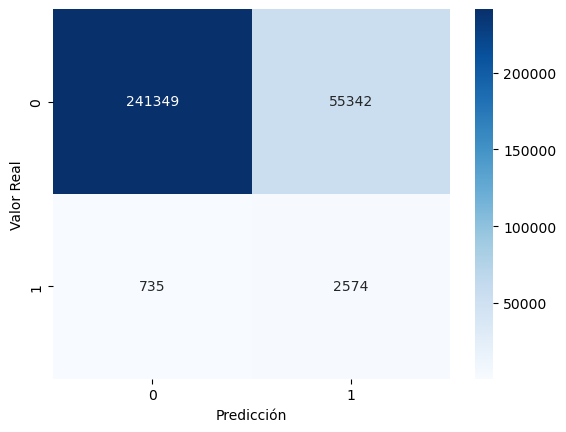

In [24]:
# 8. Entrenar todo el pipeline con una sola llamada
print("Entrenando el pipeline...")
model_pipeline.fit(X_train, y_train)
print("Entrenamiento completado.")

# 9. Hacer predicciones
y_pred = model_pipeline.predict(X_test)

# 10. Evaluar el rendimiento
print("\n--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred))

print("\n--- Matriz de Confusión ---")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.show()

In [25]:
# exportar el modelo entrenado si es necesario
import joblib
joblib.dump(model_pipeline, 'fraud-detection-webapp/model/logistic_regression_model.pkl')

['fraud-detection-webapp/model/logistic_regression_model.pkl']